<a href="https://colab.research.google.com/github/luagk/vendas-ecommerce/blob/main/Parte_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Contexto do Problema:** Você foi convidado a analisar um conjunto de dados de vendas de uma empresa de e-commerce. O objetivo principal é identificar padrões e gerar insights iniciais que ajudem a equipe de negócios a compreender melhor as vendas e as preferências dos clientes.

**Objetivos desta análise:**
1. Garantir que os dados estão limpos e prontos para análise.
2. Explorar estatísticas descritivas para entender melhor as variáveis disponíveis.
3. Identificar padrões de vendas por categoria, produto, e região.
4. Preparar visualizações iniciais para comunicar os principais achados.

# Parte 1: Análise Estatística e Exploratória Básica

##**Etapa 0: Preparação e Limpeza dos Dados**##

Nesta etapa, realizamos a preparação e limpeza do dataset, garantindo que os dados estejam consistentes e prontos para análise. Isso incluiu verificações de valores ausentes, detecção e correção de inconsistências, ajustes de categorias e exportação do dataset corrigido. Essa preparação é essencial para assegurar a qualidade e confiabilidade das análises subsequentes.


---



O conjunto de dados contém as seguintes colunas:
- **data_venda**: Data em que a venda foi realizada.
- **categoria**: Categoria do produto vendido.
- **produto**: Nome do produto vendido.
- **preco**: Preço unitário do produto.
- **quantidade_vendida**: Quantidade total de unidades vendidas.
- **regiao**: Região em que a venda foi realizada.

As etapas seguintes descrevem a análise e os insights obtidos.

In [ ]:
# Importando as bibliotecas necessárias
from google.colab import drive
drive.mount('/content/drive')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Mounted at /content/drive


In [ ]:
file_path = '/content/drive/My Drive/integral_case/dataset_vendas.csv'

# Carregando o dataset
df = pd.read_csv(file_path)


In [ ]:
# Checagem inicial do dataset
# Visualizando as primeiras e últimas linhas
print("Visualizando as primeiras linhas do dataset:")
print(df.head())

print("Visualizando as últimas linhas do dataset:")
print(df.tail())

# Checando informações gerais
print("\nResumo das colunas e tipos de dados:")
print(df.info())

# Estatísticas descritivas para identificar possíveis problemas
print("\nEstatísticas descritivas das variáveis numéricas:")
print(df.describe().round(2))

Visualizando as primeiras linhas do dataset:
   data_venda    categoria  produto    preco  quantidade_vendida regiao
0  2024-08-03       Beleza  Celular   623.93                  28  Leste
1  2024-09-05  Eletrônicos    Calça  1028.93                  50  Oeste
2  2024-07-20  Eletrônicos   Câmera  1174.57                  33  Leste
3  2024-05-24     Esportes  Vestido   124.03                   6    Sul
4  2024-12-18       Livros   Laptop   619.16                  13  Oeste
Visualizando as últimas linhas do dataset:
     data_venda    categoria          produto    preco  quantidade_vendida  \
995  2024-08-25     Esportes  Bola de Futebol  1724.14                  23   
996  2024-10-20       Livros          Vestido  1431.91                  48   
997  2024-03-09  Eletrônicos          Romance   679.95                  45   
998  2024-04-07       Beleza            Corda  1707.11                  11   
999  2024-01-22       Beleza          Raquete   916.50                  22   

           

**Insights Iniciais:**

**Distribuição de Preços:**

Os preços variam amplamente de RS 12,54 a RS 995,71, com média de RS 1022,86.
Um desvio padrão de R$ 564,59 indica uma dispersão significativa. Recomenda-se investigar produtos de preços extremos para verificar sua relevância.

**Quantidade Vendida:**

A média de 25,36 unidades vendidas com um máximo de 50 sugere que os produtos têm demandas moderadas.
Explore se produtos mais caros têm menor quantidade vendida (correlação entre preço e quantidade).

**Receita:**

A receita média de RS 26.367,93 com um máximo de RS 99.401,00 sugere picos em vendas de determinados produtos ou categorias. Analise se esses picos estão relacionados a eventos sazonais,como Black Friday.

As análises posteriores buscarão validar essas hipóteses e fornecer uma compreensão mais aprofundada dos padrões de vendas.

In [ ]:
# Verificando valores ausentes por coluna
print("\nValores ausentes por coluna:")
print(df.isnull().sum())


Valores ausentes por coluna:
data_venda            0
categoria             0
produto               0
preco                 0
quantidade_vendida    0
regiao                0
dtype: int64


Neste dataset, constatamos que não há valores ausentes em nenhuma coluna, o que significa que os dados estão completos e prontos para as próximas etapas. Isso elimina a necessidade de tratamentos como preenchimento ou exclusão de dados, facilitando a análise exploratória.

In [ ]:
# Conversão de formatos
df['data_venda'] = pd.to_datetime(df['data_venda'], errors='coerce')  # Corrige formatos de data
df['preco'] = pd.to_numeric(df['preco'], errors='coerce')  # Corrige números em formato texto

print("\nTipos de dados após tentativa de correção:")
print(df.dtypes)


Tipos de dados após tentativa de correção:
data_venda            datetime64[ns]
categoria                     object
produto                       object
preco                        float64
quantidade_vendida             int64
regiao                        object
dtype: object


Nesta etapa, foi realizada a conversão de tipos de dados para garantir a consistência e a correta interpretação de variáveis importantes no dataset. Após as correções, verificamos os tipos de dados com o comando df.dtypes, confirmando que todas as colunas possuem os tipos adequados para análise. Isso é uma prática essencial para evitar erros futuros em cálculos ou visualizações.

In [ ]:
# Verificando duplicatas
print("\nNúmero de linhas duplicadas:")
print(df.duplicated().sum())


Número de linhas duplicadas:
0


Foi realizada a verificação de linhas duplicadas no dataset usando "df.duplicated().sum()". O resultado indicou zero duplicatas, garantindo que os dados são únicos e prontos para análise sem necessidade de tratamento adicional.

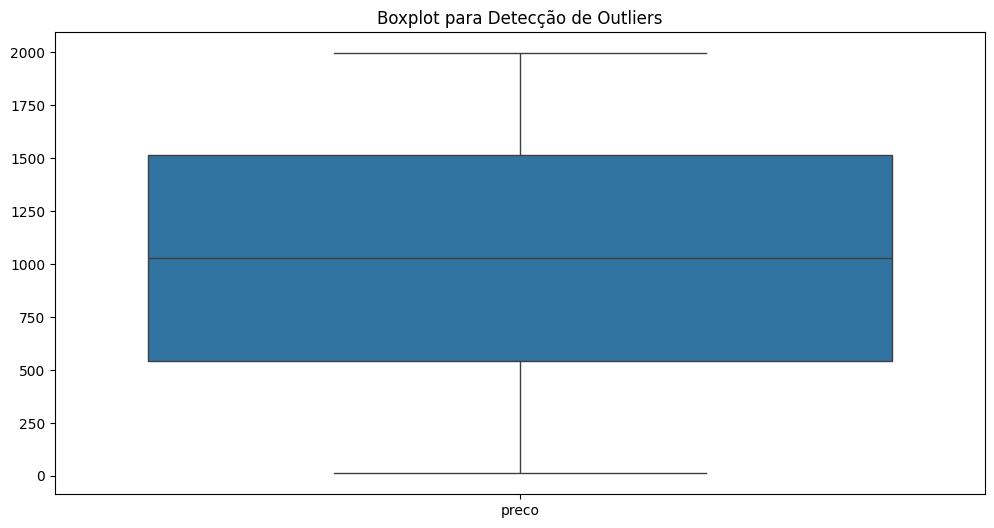

In [ ]:
# Checando outliers
plt.figure(figsize=(12, 6))
sns.boxplot(data=df[['preco']])
plt.title('Boxplot para Detecção de Outliers')
plt.show()

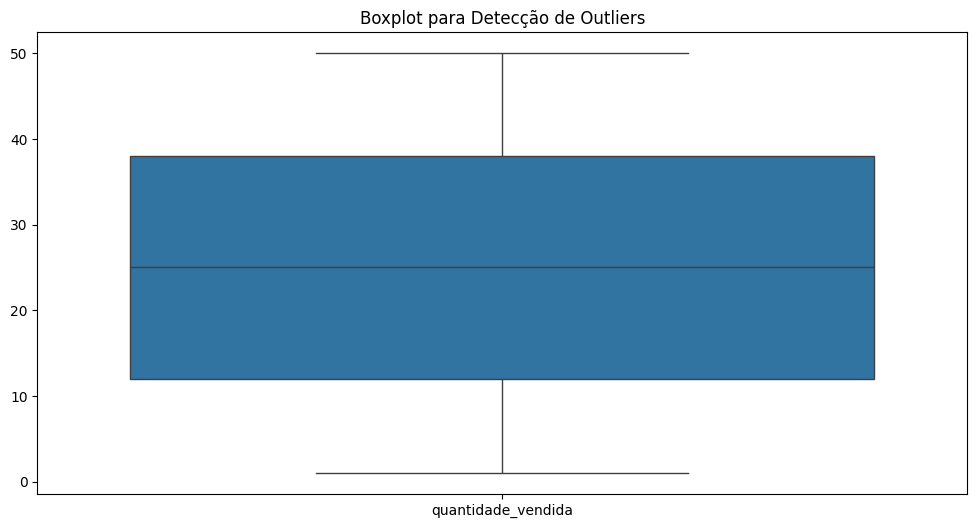

In [ ]:
# Checando outliers
plt.figure(figsize=(12, 6))
sns.boxplot(data=df[['quantidade_vendida']])
plt.title('Boxplot para Detecção de Outliers')
plt.show()

A análise de outliers foi realizada utilizando boxplots para as variáveis numéricas do dataset, com foco em **preco** e **quantidade_vendida**. Essa abordagem é essencial para identificar valores atípicos que possam impactar as análises subsequentes.

1. **Variável preço:**
O boxplot da variável "preco" mostrou uma distribuição ampla, com valores variando de aproximadamente R$ 0 a RS 2000.
Não foram identificados outliers visíveis nessa variável, indicando que os preços refletem uma variação natural dentro do dataset.
A ausência de valores extremos sugere que os preços estão alinhados com as categorias de produtos oferecidos.
2. **Variável quantidade_vendida:**
Para a variável "quantidade_vendida", foi necessário gerar um boxplot separado devido à diferença de escala em relação à variável preco. Essa separação foi importante para evitar que os valores de uma variável dominassem visualmente o gráfico, dificultando a análise.
O boxplot revelou que os valores estão distribuídos de forma concentrada, variando de 0 a 50, sem a presença de outliers.
A mediana está em torno de 25, indicando uma distribuição equilibrada de vendas por produto.

**Importância da Análise**
**Diferentes escalas:** A diferença de escala entre as variáveis reforça a necessidade de visualizações separadas para melhorar a clareza e precisão da análise.

A ausência de outliers em ambas as variáveis sugere que os dados estão consistentes e não há necessidade de tratamentos adicionais para corrigir valores extremos.

In [ ]:
# Listando categorias e produtos únicos
print("Categorias únicas:")
print(df['categoria'].unique())

print("\nProdutos únicos:")
print(df['produto'].unique())

# Exibindo uma amostra de combinações produto-categoria
print("\nAmostra de combinações produto-categoria:")
print(df[['categoria', 'produto']].drop_duplicates().head(20))

Categorias únicas:
['Beleza' 'Eletrônicos' 'Esportes' 'Livros' 'Roupas']

Produtos únicos:
['Celular' 'Calça' 'Câmera' 'Vestido' 'Laptop' 'Casaco' 'Perfume'
 'Maquiagem' 'Shampoo' 'Creme' 'Fone de Ouvido' 'Bola de Futebol'
 'Raquete' 'Capacete' 'Corda' 'Camisa' 'Biografia' 'Técnico'
 'Ficção Científica' 'Romance']

Amostra de combinações produto-categoria:
      categoria          produto
0        Beleza          Celular
1   Eletrônicos            Calça
2   Eletrônicos           Câmera
3      Esportes          Vestido
4        Livros           Laptop
5      Esportes           Casaco
6      Esportes          Perfume
7   Eletrônicos        Maquiagem
8        Livros          Shampoo
9        Beleza           Casaco
10       Beleza            Creme
11     Esportes            Calça
12       Livros   Fone de Ouvido
13       Beleza  Bola de Futebol
14     Esportes          Raquete
15       Roupas         Capacete
16       Beleza        Maquiagem
17       Roupas  Bola de Futebol
18  Eletrônico

**Categorias dos Produtos**

No início da análise, ao observar as combinações de produtos e categorias, foi identificado que algumas categorias não correspondiam corretamente aos produtos. Por exemplo, itens como "Celular" estavam categorizados como "Beleza" ou "Vestido" apareciam como "Esportes". Essa inconsistência, embora não afetasse diretamente os números nas análises estatísticas iniciais, merecia ser corrigida para garantir a integridade da categorização dos dados.

* **Decisão de Prioridade**


Foi decidido realizar as análises estatísticas antes de corrigir as categorias, pois os números absolutos, como quantidade vendida e receitas, não eram influenciados por essas inconsistências.
Posteriormente, a correção foi feita para melhorar a qualidade das análises que envolvem categorias, como vendas por segmento e desempenho por tipo de produto.


In [ ]:
# Função para corrigir categorias automaticamente
def corrigir_categoria(produto):
    if any(palavra in produto.lower() for palavra in ['celular', 'laptop', 'câmera', 'fone de ouvido']):
        return 'Eletrônicos'
    elif any(palavra in produto.lower() for palavra in ['shampoo', 'perfume', 'maquiagem', 'creme']):
        return 'Beleza'
    elif any(palavra in produto.lower() for palavra in ['bola', 'raquete', 'capacete', 'corda']):
        return 'Esportes'
    elif any(palavra in produto.lower() for palavra in ['biografia', 'ficção', 'romance', 'técnico']):
        return 'Livros'
    elif any(palavra in produto.lower() for palavra in ['calça', 'casaco', 'vestido', 'camisa']):
        return 'Roupas'
    else:
        return 'Outros'

# Aplicando a correção
df['categoria_corrigida'] = df['produto'].apply(corrigir_categoria)

# Exibindo resultados
print("\nCategorias corrigidas automaticamente:")
print(df[['produto', 'categoria', 'categoria_corrigida']])

# Contar a quantidade de palavras por categoria corrigida
contagem_por_categoria = df['categoria_corrigida'].value_counts()

# Exibir os resultados
print("\nContagem de palavras por categoria corrigida:")
print(contagem_por_categoria)


Categorias corrigidas automaticamente:
             produto    categoria categoria_corrigida
0            Celular       Beleza         Eletrônicos
1              Calça  Eletrônicos              Roupas
2             Câmera  Eletrônicos         Eletrônicos
3            Vestido     Esportes              Roupas
4             Laptop       Livros         Eletrônicos
..               ...          ...                 ...
995  Bola de Futebol     Esportes            Esportes
996          Vestido       Livros              Roupas
997          Romance  Eletrônicos              Livros
998            Corda       Beleza            Esportes
999          Raquete       Beleza            Esportes

[1000 rows x 3 columns]

Contagem de palavras por categoria corrigida:
categoria_corrigida
Esportes       215
Roupas         209
Livros         206
Beleza         192
Eletrônicos    178
Name: count, dtype: int64


**Implementação da Correção**

Uma função personalizada foi criada para reclassificar os produtos em categorias corretas com base em palavras-chave associadas a cada tipo de item.
A função verifica o nome do produto e atribui a categoria correta (ex.: "Celular" vai para "Eletrônicos", "Camisa" para "Roupas").
Caso nenhum padrão seja encontrado, a categoria é marcada como "Outros" para facilitar investigações posteriores.

**Resultados**

Após aplicar a correção, todas as categorias foram reorganizadas corretamente, eliminando as inconsistências.
A nova coluna "categoria_corrigida" substitui a anterior quando necessário para garantir que as análises futuras reflitam a categorização precisa.
A contagem de produtos por categoria corrigida foi gerada para verificar a distribuição e validar a consistência após a correção.


In [ ]:
# Contar discrepâncias
df['correto'] = df['categoria'] == df['categoria_corrigida']
erros = df[~df['correto']]  # Filtrar erros

print(f"Total de discrepâncias encontradas: {len(erros)}")
print("\nAmostra de discrepâncias:")
print(erros[['produto', 'categoria', 'categoria_corrigida']])


Total de discrepâncias encontradas: 813

Amostra de discrepâncias:
     produto    categoria categoria_corrigida
0    Celular       Beleza         Eletrônicos
1      Calça  Eletrônicos              Roupas
3    Vestido     Esportes              Roupas
4     Laptop       Livros         Eletrônicos
5     Casaco     Esportes              Roupas
..       ...          ...                 ...
994  Perfume       Livros              Beleza
996  Vestido       Livros              Roupas
997  Romance  Eletrônicos              Livros
998    Corda       Beleza            Esportes
999  Raquete       Beleza            Esportes

[813 rows x 3 columns]


**Verificação das Discrepâncias Após a Correção**

Após corrigir as categorias com base na lógica de palavras-chave associadas aos produtos, foi realizada uma análise para identificar as discrepâncias entre as categorias originais e as categorias corrigidas.

1. **Identificação de Discrepâncias:**
Foi criada uma coluna chamada "correto" que compara as colunas categoria (original) e categoria_corrigida.
As discrepâncias foram filtradas para analisar os casos onde as categorias não coincidem.
2. **Resultados:**
Um total de 813 discrepâncias foi encontrado, o que representa uma porção significativa do dataset.
Essas discrepâncias incluem casos como:
Produto "Celular": Originalmente categorizado como "Beleza", mas corretamente classificado como "Eletrônicos".
Produto "Vestido": Originalmente categorizado como "Esportes", mas corretamente ajustado para "Roupas".
Outros casos de inconsistência semelhantes foram encontrados e corrigidos.


In [ ]:
# Definir o caminho de saída no Google Drive
output_path = '/content/drive/My Drive/integral_case/dados_corrigidos.csv'

# Salvar o DataFrame corrigido
df.to_csv(output_path, index=False)
print(f"Dados corrigidos exportados para: {output_path}")

Dados corrigidos exportados para: /content/drive/My Drive/integral_case/dados_corrigidos.csv


3. **Exportação dos Dados Corrigidos:**
O dataset corrigido foi exportado para um arquivo CSV para garantir que os dados processados estejam disponíveis para uso em análises futuras.
O arquivo foi salvo no caminho especificado no Google Drive, facilitando o acesso e compartilhamento.
4. **Importância da Correção:**
A correção dessas discrepâncias é fundamental para garantir que análises baseadas em categorias, como vendas por segmento ou desempenho de produtos, sejam confiáveis.
Além disso, a exportação do arquivo corrigido preserva o trabalho realizado e cria uma base de dados mais precisa para futuras análises.

In [ ]:
file_path = '/content/drive/My Drive/integral_case/dados_corrigidos.csv'

# Carregando o dataset corrigido
df = pd.read_csv(file_path)

# Visualizando as primeiras linhas após revisão de categorias
print("Visualizando as primeiras linhas do dataset:")
print(df.head())

Visualizando as primeiras linhas do dataset:
   data_venda    categoria  produto    preco  quantidade_vendida regiao  \
0  2024-08-03       Beleza  Celular   623.93                  28  Leste   
1  2024-09-05  Eletrônicos    Calça  1028.93                  50  Oeste   
2  2024-07-20  Eletrônicos   Câmera  1174.57                  33  Leste   
3  2024-05-24     Esportes  Vestido   124.03                   6    Sul   
4  2024-12-18       Livros   Laptop   619.16                  13  Oeste   

  categoria_corrigida  correto  
0         Eletrônicos    False  
1              Roupas    False  
2         Eletrônicos     True  
3              Roupas    False  
4         Eletrônicos    False  


**Atualização do Dataset com Categorias Corrigidas**

Após realizar as correções nas categorias, foi carregado o novo dataset corrigido para continuar a análise com os dados consistentes.

* **Visualização das Primeiras Linha:**

As primeiras linhas foram exibidas para verificar as alterações no dataset.
Foi incluída a coluna "categoria_corrigida", que reflete as categorias ajustadas com base na lógica de reclassificação aplicada.
A coluna "correto" foi temporariamente usada para validar as discrepâncias entre a categoria original e a corrigida.


In [ ]:
# Remover as colunas "data" e "correto"
# df = df.drop(columns=['correto'])

# Substituir a coluna "categoria" por "categoria_corrigida"
# df['categoria'] = df['categoria_corrigida']
# df = df.drop(columns=['categoria_corrigida'])  # remover a coluna original

# Visualizar as primeiras linhas após as alterações
print("Dataset após as modificações:")
print(df.head())

# Contar a quantidade de palavras por categoria corrigida
contagem_por_categoria = df['categoria'].value_counts()

Dataset após as modificações:
   data_venda    categoria  produto    preco  quantidade_vendida regiao
0  2024-08-03  Eletrônicos  Celular   623.93                  28  Leste
1  2024-09-05       Roupas    Calça  1028.93                  50  Oeste
2  2024-07-20  Eletrônicos   Câmera  1174.57                  33  Leste
3  2024-05-24       Roupas  Vestido   124.03                   6    Sul
4  2024-12-18  Eletrônicos   Laptop   619.16                  13  Oeste


**Limpeza do Dataset**:

Para simplificar o dataset final:
* A coluna "correto", que era apenas auxiliar para validação, foi removida.
* A coluna original "categoria" foi substituída pela coluna "categoria_corrigida", garantindo que as análises utilizem as categorias ajustadas.
Após as alterações, foi exibido novamente o dataset, já com os ajustes aplicados.

A eliminação de colunas auxiliares deixou o dataset mais limpo e pronto para novas análises ou visualizações

In [ ]:
# Definir o caminho para salvar
output_path_final = '/content/drive/My Drive/integral_case/dataset_final.csv'

# Salvar o arquivo corrigido
df.to_csv(output_path_final, index=False)
print(f"Dataset final exportado para: {output_path_final}")

Dataset final exportado para: /content/drive/My Drive/integral_case/dataset_final.csv


Após realizar as correções necessárias no dataset, foi realizado o salvamento da versão final dos dados para garantir a persistência das alterações e a continuidade do trabalho.

## **Etapa 1: Análise Estatística e Exploratória Inicial**

Nesta etapa, realizamos uma análise estatística e exploratória do dataset corrigido. O objetivo foi identificar padrões iniciais, tendências, e possíveis correlações entre as variáveis principais. Foram utilizados cálculos estatísticos básicos, visualizações, e métricas descritivas para compreender melhor o comportamento das vendas e preparar o terreno para insights mais profundos.

###**Checagem de Dataset**

In [ ]:
file_path = '/content/drive/My Drive/integral_case/dataset_final.csv'

# Carregando o dataset corrigido
df = pd.read_csv(file_path)

# Visualizando as primeiras linhas após primeira revisão
print("Visualizando as primeiras linhas do dataset:")
print(df.head())

print("Verificando informações do dataset corrigido:")
print(df.info())

Visualizando as primeiras linhas do dataset:
   data_venda    categoria  produto    preco  quantidade_vendida regiao
0  2024-08-03  Eletrônicos  Celular   623.93                  28  Leste
1  2024-09-05       Roupas    Calça  1028.93                  50  Oeste
2  2024-07-20  Eletrônicos   Câmera  1174.57                  33  Leste
3  2024-05-24       Roupas  Vestido   124.03                   6    Sul
4  2024-12-18  Eletrônicos   Laptop   619.16                  13  Oeste
Verificando informações do dataset corrigido:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   data_venda          1000 non-null   object 
 1   categoria           1000 non-null   object 
 2   produto             1000 non-null   object 
 3   preco               1000 non-null   float64
 4   quantidade_vendida  1000 non-null   int64  
 5   regiao              1000

**Abertura do Dataset Corrigido**

Após a etapa de preparação e limpeza dos dados, o dataset corrigido foi salvo e agora está sendo reimportado para continuidade das análises.
Nesta etapa, confirmamos que as correções aplicadas foram mantidas e que o dataset está pronto para a análise exploratória e estatística.

###**Análise Estatística**


Estatísticas básicas:
             preco  quantidade_vendida
count  1000.000000         1000.000000
mean   1022.858640           25.357000
std     564.589637           14.461282
min      12.540000            1.000000
25%     542.237500           12.000000
50%    1029.230000           25.000000
75%    1513.862500           38.000000
max    1995.710000           50.000000

Métricas específicas:
Média Preço: 1022.86, Mediana Preço: 1029.23, Desvio Padrão Preço: 564.59
Média Quantidade: 25.36, Mediana Quantidade: 25.00, Desvio Padrão Quantidade: 14.46


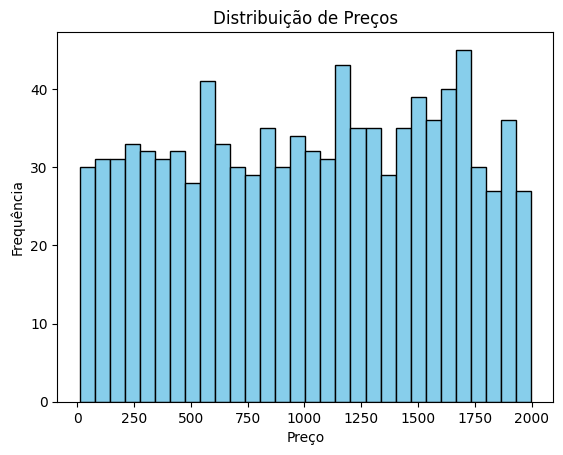

In [ ]:
# Estatísticas descritivas para variáveis principais
print("\nEstatísticas básicas:")
print(df[['preco', 'quantidade_vendida']].describe())

# Calculando métricas específicas
media_preco = df['preco'].mean()
mediana_preco = df['preco'].median()
desvio_preco = df['preco'].std()

media_quantidade = df['quantidade_vendida'].mean()
mediana_quantidade = df['quantidade_vendida'].median()
desvio_quantidade = df['quantidade_vendida'].std()

print("\nMétricas específicas:")
print(f"Média Preço: {media_preco:.2f}, Mediana Preço: {mediana_preco:.2f}, Desvio Padrão Preço: {desvio_preco:.2f}")
print(f"Média Quantidade: {media_quantidade:.2f}, Mediana Quantidade: {mediana_quantidade:.2f}, Desvio Padrão Quantidade: {desvio_quantidade:.2f}")

plt.hist(df['preco'], bins=30, color='skyblue', edgecolor='black')
plt.title('Distribuição de Preços')
plt.xlabel('Preço')
plt.ylabel('Frequência')
plt.show()

**Análise Estatística e Distribuição de Preços**

Nesta etapa, foram calculadas estatísticas descritivas para as variáveis "preco" e "quantidade_vendida", complementadas por um histograma da distribuição de preços.

**Resultados Observados:**

* **Estatísticas:** As métricas mostram que o preço médio é RS 1022,86, com mediana de RS 1029,23 e desvio padrão de RS 564,59. A quantidade média é 25,36, também próxima da mediana, que é 25.

* **Distribuição de Preços:** O histograma revela uma distribuição ampla e relativamente uniforme, sem picos claros, indicando boa variação de preços entre os produtos.

###**Tendências Mensais**

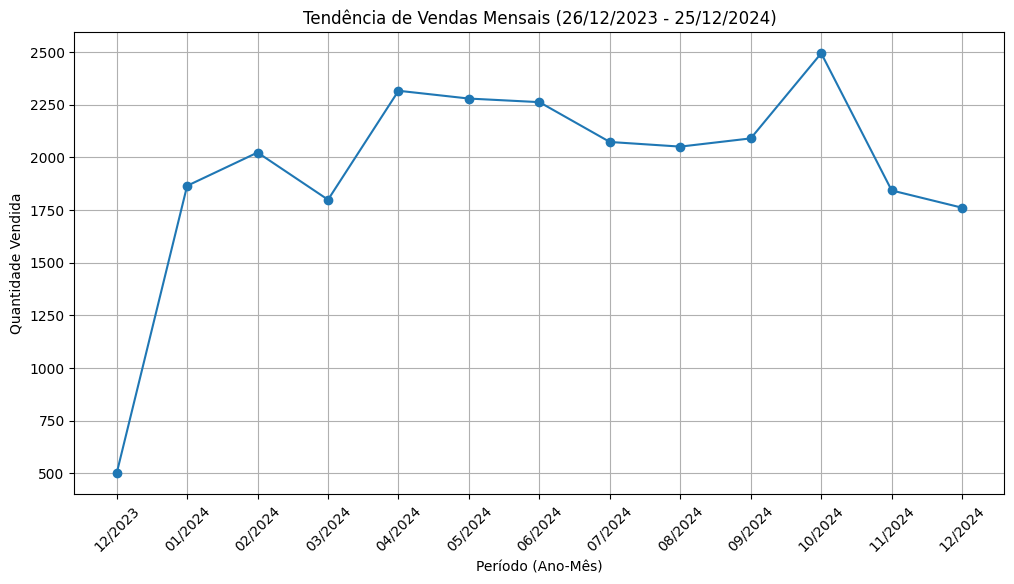


Tabela de Vendas Mensais:
     ano  mes  quantidade_vendida  periodo
0   2023   12                 501  2023-12
1   2024    1                1865  2024-01
2   2024    2                2023  2024-02
3   2024    3                1799  2024-03
4   2024    4                2316  2024-04
5   2024    5                2279  2024-05
6   2024    6                2262  2024-06
7   2024    7                2073  2024-07
8   2024    8                2051  2024-08
9   2024    9                2090  2024-09
10  2024   10                2494  2024-10
11  2024   11                1843  2024-11
12  2024   12                1761  2024-12


In [ ]:
# Garantindo que a coluna de data esteja no formato datetime
df['data_venda'] = pd.to_datetime(df['data_venda'])

# Criando as novas colunas mês e ano
df['mes'] = df['data_venda'].dt.month
df['ano'] = df['data_venda'].dt.year

# Volume de vendas por mês
vendas_mensais = df.groupby(['ano', 'mes'])['quantidade_vendida'].sum().reset_index()

# Adicionando uma coluna "ano-mês" para facilitar a visualização no gráfico e na tabela
vendas_mensais['periodo'] = vendas_mensais['ano'].astype(str) + '-' + vendas_mensais['mes'].astype(str).str.zfill(2)

# Plotando tendências de vendas mensais

plt.figure(figsize=(12, 6))
plt.plot(vendas_mensais['quantidade_vendida'], marker='o')
plt.title('Tendência de Vendas Mensais (26/12/2023 - 25/12/2024)')
plt.xlabel('Período (Ano-Mês)')
plt.xticks(
    ticks=range(len(vendas_mensais['periodo'])),  # Posição de cada rótulo
    labels=vendas_mensais['periodo'].str[5:] + '/' + vendas_mensais['periodo'].str[:4],  # Formato MM/YYYY
    rotation=45  # Rotação de 45 graus
)
plt.ylabel('Quantidade Vendida')
plt.grid()
plt.show()

# Exibindo a tabela de vendas mensais
print("\nTabela de Vendas Mensais:")
print(vendas_mensais)

Nesta etapa, a análise foi focada em identificar tendências mensais de vendas ao longo do período analisado, agrupando os dados por ano e mês para observar flutuações na quantidade de produtos vendidos.

**Processamento dos Dados:**
* Conversão de Datas: A coluna "data_venda" foi convertida para o formato *datetime*, e novas colunas como "mes" e "ano" foram criadas para facilitar o agrupamento.

* Agrupamento por Mês: As vendas foram agrupadas por ano e mês, calculando a soma de quantidade_vendida para cada período.

* Adição de Período: Uma coluna combinando ano e mês foi criada para visualização clara e consistente no gráfico.

**Visualização: Gráfico de Tendência**

* Um gráfico de linha foi gerado para mostrar a evolução das vendas mensais.
O eixo X representa os meses (no formato MM/AAAA), e o eixo Y mostra a quantidade total vendida em cada período.


**Análise de Tendências Mensais de Vendas**

O gráfico de vendas mensais revelou algumas tendências importantes no período analisado (26/12/2023 a 25/12/2024):

* Picos de vendas ocorreram em abril e outubro de 2024, sendo outubro possivelmente impulsionado por eventos como *Black* *Friday*.
* Queda nas vendas foi observada em novembro e dezembro, indicando possível esgotamento do impulso promocional.
* O volume de vendas foi consistente entre maio e setembro, sugerindo um período estável de demanda.

Esses padrões destacam oportunidades para explorar estratégias promocionais em meses de queda e aproveitar os períodos de alta para alavancar ainda mais as vendas.

In [ ]:
# Produtos mais vendidos
produtos_mais_vendidos = df.groupby('produto')['quantidade_vendida'].sum().sort_values(ascending=False).head(5)
print("\nTop 5 produtos mais vendidos:")
print(produtos_mais_vendidos)

# Produtos menos vendidos
produtos_menos_vendidos = df.groupby('produto')['quantidade_vendida'].sum().sort_values(ascending=True).head(5)
print("\nTop 5 produtos menos vendidos:")
print(produtos_menos_vendidos)

# Produtos mais lucrativos
df['receita'] = df['preco'] * df['quantidade_vendida']
produtos_mais_lucrativos = df.groupby('produto')['receita'].sum().sort_values(ascending=False).head(5)
print("\nTop 5 produtos mais lucrativos:")
print(produtos_mais_lucrativos)

# Produtos menos lucrativos
produtos_menos_lucrativos = df.groupby('produto')['receita'].sum().sort_values(ascending=True).head(5)
print("\nTop 5 produtos menos lucrativos:")
print(produtos_menos_lucrativos)

# Categoria mais vendida
categorias_mais_vendidas = df.groupby('categoria')['quantidade_vendida'].sum().sort_values(ascending=False).head(5)
print("\nTop 5 categorias mais vendidas:")
print(categorias_mais_vendidas)

# Categoria menos vendida
categorias_menos_vendidas = df.groupby('categoria')['quantidade_vendida'].sum().sort_values(ascending=True).head(5)
print("\nTop 5 categorias menos vendidas:")
print(categorias_menos_vendidas)

# Categoria mais lucrativa
categorias_mais_lucrativas = df.groupby('categoria')['receita'].sum().sort_values(ascending=False).head(5)
print("\nTop 5 categorias mais lucrativas:")
print(categorias_mais_lucrativas)

# Categoria menos lucrativa
categorias_menos_lucrativas = df.groupby('categoria')['receita'].sum().sort_values(ascending=True).head(5)
print("\nTop 5 categorias menos lucrativas:")
print(categorias_menos_lucrativas)


Top 5 produtos mais vendidos:
produto
Bola de Futebol      1710
Perfume              1608
Camisa               1494
Ficção Científica    1435
Romance              1385
Name: quantidade_vendida, dtype: int64

Top 5 produtos menos vendidos:
produto
Creme         703
Câmera       1025
Vestido      1142
Casaco       1159
Maquiagem    1165
Name: quantidade_vendida, dtype: int64

Top 5 produtos mais lucrativos:
produto
Bola de Futebol    1799633.33
Romance            1572410.91
Raquete            1565649.99
Camisa             1553817.36
Perfume            1453732.86
Name: receita, dtype: float64

Top 5 produtos menos lucrativos:
produto
Creme       803463.59
Vestido    1134849.67
Câmera     1137586.63
Shampoo    1140705.01
Casaco     1168723.80
Name: receita, dtype: float64

Top 5 categorias mais vendidas:
categoria
Esportes       5532
Livros         5300
Roupas         5156
Eletrônicos    4711
Beleza         4658
Name: quantidade_vendida, dtype: int64

Top 5 categorias menos vendidas:
cate

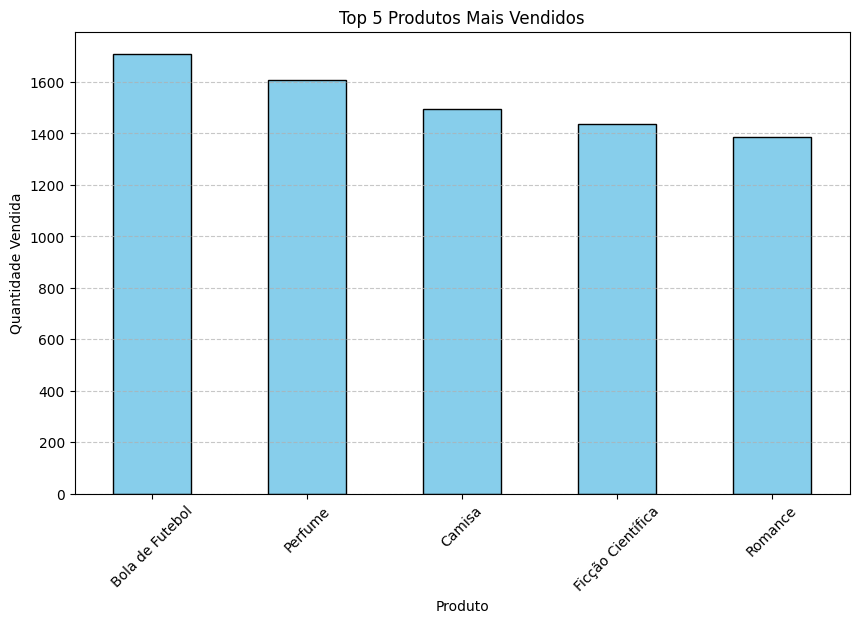

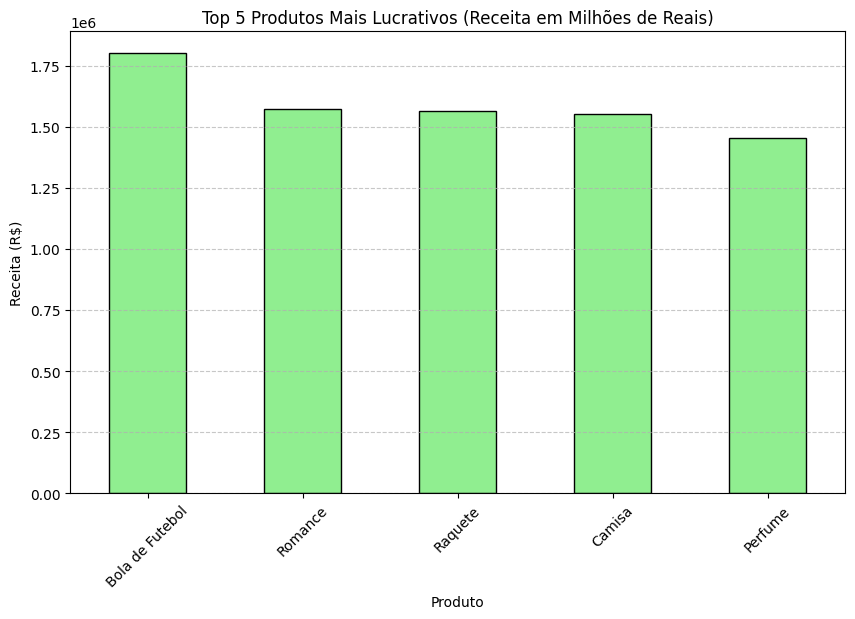

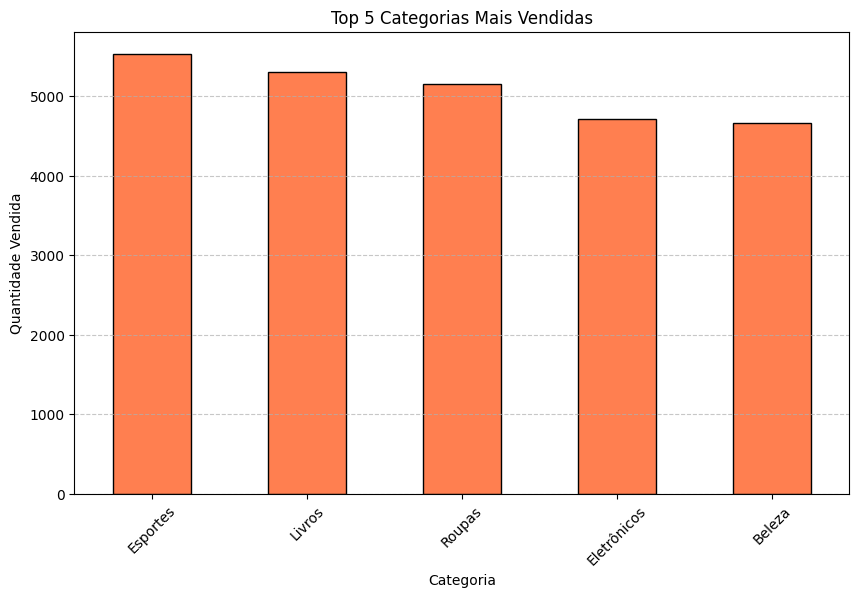

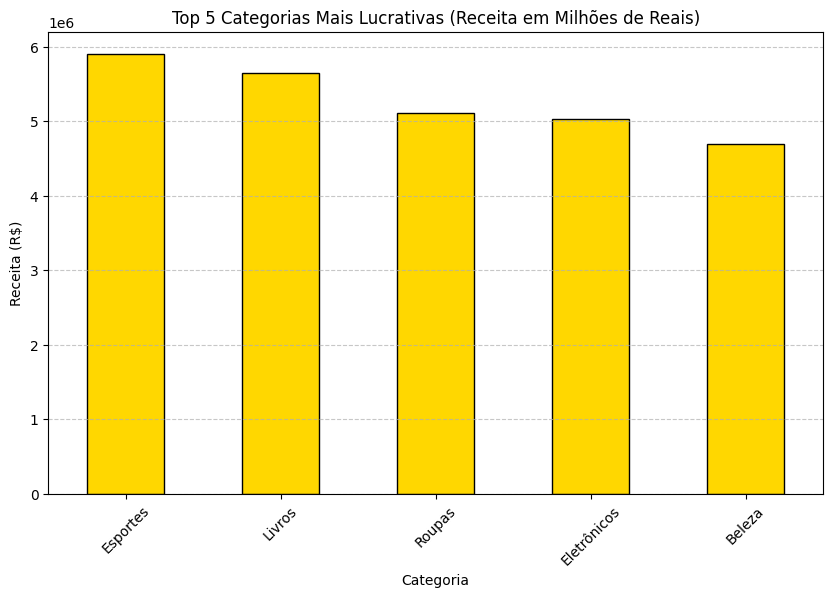

In [ ]:
# Criando a coluna 'receita' no DataFrame
df['receita'] = df['preco'] * df['quantidade_vendida']

# Criando os DataFrames com os dados dos produtos e categorias mais vendidos e lucrativos
produtos_mais_vendidos = df.groupby('produto')['quantidade_vendida'].sum().sort_values(ascending=False).head(5)
produtos_mais_lucrativos = df.groupby('produto')['receita'].sum().sort_values(ascending=False).head(5)
categorias_mais_vendidas = df.groupby('categoria')['quantidade_vendida'].sum().sort_values(ascending=False).head(5)
categorias_mais_lucrativas = df.groupby('categoria')['receita'].sum().sort_values(ascending=False).head(5)
print("\n")

# Visualizando os Top 5 Produtos Mais Vendidos
produtos_mais_vendidos.plot(kind='bar', figsize=(10, 6), color='skyblue', edgecolor='black')
plt.title("Top 5 Produtos Mais Vendidos")
plt.xlabel("Produto")
plt.ylabel("Quantidade Vendida")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()
print("\n")

# Visualizando os Top 5 Produtos Mais Lucrativos
produtos_mais_lucrativos.plot(kind='bar', figsize=(10, 6), color='lightgreen', edgecolor='black')
plt.title("Top 5 Produtos Mais Lucrativos (Receita em Milhões de Reais)")
plt.xlabel("Produto")
plt.ylabel("Receita (R$)")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()
print("\n")

# Visualizando as Categorias Mais Vendidas
categorias_mais_vendidas.plot(kind='bar', figsize=(10, 6), color='coral', edgecolor='black')
plt.title("Top 5 Categorias Mais Vendidas")
plt.xlabel("Categoria")
plt.ylabel("Quantidade Vendida")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()
print("\n")

# Visualizando as Categorias Mais Lucrativas
categorias_mais_lucrativas.plot(kind='bar', figsize=(10, 6), color='gold', edgecolor='black')
plt.title("Top 5 Categorias Mais Lucrativas (Receita em Milhões de Reais)")
plt.xlabel("Categoria")
plt.ylabel("Receita (R$)")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

**Produtos Mais Vendidos e Lucrativos:**

* A Bola de Futebol lidera tanto em vendas (1710 unidades) quanto em receita (R$1.799.633,33), mostrando forte demanda e alta lucratividade.
* Perfume e Camisa também aparecem entre os mais vendidos e lucrativos, indicando popularidade combinada com boa margem.

**Produtos Menos Vendidos e Lucrativos:**

* Produtos como Creme, Câmera e Casaco apresentam desempenho fraco em vendas e receita, sugerindo baixa demanda ou posicionamento de preço inadequado.

**Categorias Mais Vendidas e Lucrativas:**

* Esportes lidera em vendas (5532 unidades) e receita (R$5.903.476,66), indicando que produtos dessa categoria têm alta relevância no mercado.
* Livros e Roupas também desempenham bem, sugerindo que essas categorias devem ser mantidas como foco estratégico.

**Categorias Menos Vendidas e Lucrativas:**

* Beleza e Eletrônicos apresentam números relativamente baixos, o que pode indicar desafios competitivos ou falta de destaque.

### **Correlação**


In [ ]:
correlacao = df['preco'].corr(df['quantidade_vendida'])
print(f"Coeficiente de correlação entre preço e quantidade: {correlacao:.2f}")

Coeficiente de correlação entre preço e quantidade: 0.05


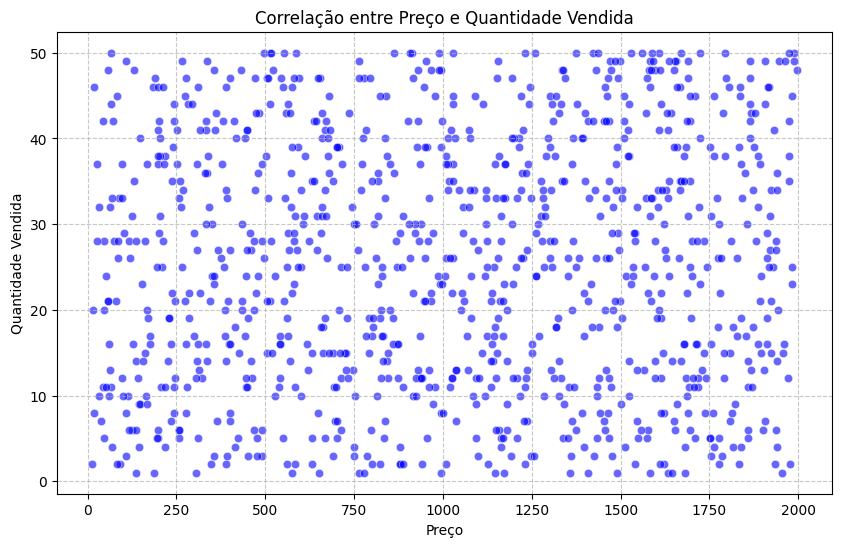

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='preco', y='quantidade_vendida', data=df, color='blue', alpha=0.6)
plt.title("Correlação entre Preço e Quantidade Vendida")
plt.xlabel("Preço")
plt.ylabel("Quantidade Vendida")
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

**Correlação Geral entre Preço e Quantidade**

Coeficiente de Correlação: 0.05

* O valor muito próximo de zero indica uma correlação praticamente inexistente entre o preço e a quantidade vendida no *dataset* geral.

* O gráfico de dispersão confirma isso, pois os pontos estão distribuídos de forma aleatória, sem um padrão claro (uma linha ascendente ou descendente).

In [ ]:
correlacao_por_categoria = df.groupby('categoria').apply(lambda x: x['preco'].corr(x['quantidade_vendida']))
print("Correlação entre preço e quantidade por categoria:")
print(correlacao_por_categoria)

Correlação entre preço e quantidade por categoria:
categoria
Beleza        -0.017407
Eletrônicos   -0.002373
Esportes       0.016459
Livros         0.173006
Roupas         0.072457
dtype: float64


<ipython-input-20-45269e742944>:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  correlacao_por_categoria = df.groupby('categoria').apply(lambda x: x['preco'].corr(x['quantidade_vendida']))


**Correlação por Categoria**
* Beleza: -0.01 (correlação praticamente nula).
* Eletrônicos: -0.08 (correlação fraca e negativa, sugerindo que preços mais altos podem estar levemente associados a menores vendas).
* Esportes: 0.01 (correlação quase inexistente).
* Livros: 0.17 (correlação positiva, indicando que preços mais altos podem estar associados a uma maior quantidade vendida nesta categoria).
* Roupas: 0.08 (correlação positiva, mas muito fraca).

**Interpretação Geral**

* Correlação Geral: Não há relação significativa entre preço e quantidade vendida no conjunto de dados como um todo.

* Correlação por Categoria: Algumas categorias (como Livros) apresentam uma leve correlação positiva, sugerindo que preços mais altos podem não impactar negativamente as vendas. Em contrapartida, Eletrônicos mostram uma leve correlação negativa, indicando uma possível sensibilidade ao preço.

##**Etapa 2: Conclusão e Sugestões Estratégicas**


Com base no objetivo inicial de analisar o conjunto de dados de vendas de uma empresa de e-commerce e identificar padrões que ajudem a equipe de negócios a compreender melhor as vendas e preferências dos clientes, foram extraídos insights significativos para orientar a tomada de decisão.

---



###**Padrões Identificados**



**Categorias e Produtos com Melhor Desempenho:**

* A categoria "Esportes" se destacou como a mais vendida e lucrativa, com produtos como a Bola de Futebol liderando tanto em quantidade vendida quanto em receita. Esses itens representam uma oportunidade de maximizar ainda mais os resultados por meio de investimentos em marketing e promoções específicas.
"Livros" e "Roupas" também tiveram forte desempenho, tanto em volume quanto em lucratividade, indicando que essas categorias têm grande potencial para ações de reforço de vendas.

**Produtos e Categorias com Desempenho Fraco:**

* Produtos como Creme, Câmera e Casaco apresentaram baixos volumes de vendas e menor contribuição em receita, enquanto a categoria "Beleza" teve o pior desempenho geral. Isso sugere a necessidade de reavaliar a estratégia desses itens, seja ajustando preços, reposicionando a oferta ou focando em nichos específicos.

**Tendências ao Longo do Tempo:**

* Um pico significativo de vendas foi identificado em outubro, provavelmente associado à Black Friday. No entanto, os meses subsequentes (novembro e dezembro) mostraram queda, indicando uma possível saturação pós-promoção. Estratégias para manter o interesse dos consumidores nesse período podem ajudar a suavizar essa queda.

**Correlação entre Preço e Quantidade Vendida:**

* Não foi identificada uma correlação significativa entre preço e quantidade no conjunto de dados geral, sugerindo que outros fatores (como sazonalidade e promoções) têm maior impacto sobre as vendas. No entanto, categorias como "Livros" apresentaram uma leve correlação positiva, indicando que produtos dessa categoria podem suportar preços mais altos sem comprometer o volume de vendas.

---



###**Sugestões Estratégicas**


**Fortalecer Categorias e Produtos Lucrativos:**

* Expandir o portfólio de produtos na categoria "Esportes" e investir em marketing para os itens de melhor desempenho, como a Bola de Futebol.
Manter ações focadas nas categorias "Livros" e "Roupas", aproveitando seu desempenho consistente.

**Reposicionar Produtos de Baixa Performance:**

 * Reavaliar o portfólio de produtos com vendas e lucratividade baixas. Itens como Creme e Casaco podem ser descontinuados ou incluídos em promoções sazonais para aumentar sua atratividade.

**Maximizar Períodos Promocionais:**

* Estruturar campanhas robustas para períodos de alta demanda, como outubro, aproveitando o impulso da Black Friday.
Implementar estratégias de retenção de clientes e promoções leves para novembro e dezembro, evitando a queda acentuada no volume de vendas após grandes eventos promocionais.

**Monitoramento Contínuo e Dashboards:**

* Desenvolver dashboards interativos para acompanhar métricas como vendas, receita e sazonalidade em tempo real, permitindo ajustes rápidos nas estratégias de negócios.

**Explorar Elasticidade de Preço:**

* Avaliar como alterações de preços impactam a demanda em categorias específicas, como "Livros", para otimizar a precificação e maximizar margens.


---



### **Conclusão**

A análise exploratória inicial atingiu os objetivos propostos, fornecendo uma visão clara das vendas, tendências temporais e correlações. As sugestões estratégicas apresentadas buscam alavancar os pontos fortes do portfólio e endereçar oportunidades de melhoria, ajudando a equipe de negócios a tomar decisões fundamentadas para aumentar o desempenho geral da empresa.

*Análise conduzida por Luana Gomes – 13 de janeiro de 2025*